## Age Category (Child/Teenager/Adult)

In [34]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [35]:
class AgentState(TypedDict):
    age: int
    category: str

In [36]:
def child(state: AgentState) -> AgentState:
    """This node checks if the age lies in child category."""

    if state['age'] < 13:
        state['category'] = 'child'
        return state

def teenager(state: AgentState) -> AgentState:
    if 13 < state[age] < 20:
        state['category'] = 'teenager'
        return state
    
def adult(state: AgentState) -> AgentState:    
    if state['age'] > 20:
        state['category'] = 'adult'
        return state
    
def check_age(state: AgentState) -> AgentState:
    if state['age'] < 13:
        return "childd"
    elif 13 < state['age'] < 20:
        return "teenagerr"
    elif state['age'] > 20:
        return "adultt"
    else:
        return "invalid"
    

In [37]:
graph = StateGraph(AgentState)

graph.add_node("child", child)
graph.add_node("teenager", teenager)
graph.add_node("adult", adult)
graph.add_node("router", lambda state: state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router",
    check_age,
        {
            "childd": "child",
            "teenagerr": "teenager",
            "adultt": "adult"
        }
)

graph.add_edge("child", END)
graph.add_edge("teenager", END)
graph.add_edge("adult", END)

app = graph.compile()

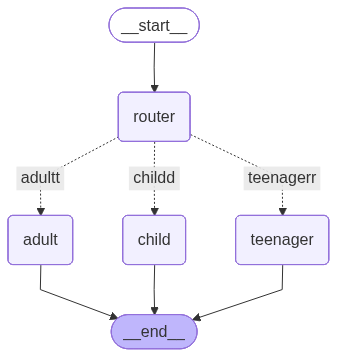

In [38]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png()))

In [39]:
answer = app.invoke({"age": 25})
print(answer['category'])

adult
